In [1]:
%load_ext autoreload
%autoreload 2

import logging
import os
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#os.chdir(os.environ.get("PROJECT_ROOT", "../.."))

from src.experiments_analysis.cell_typing_pipeline import (
    compare_cell_types,
    load_benchmark_config,
    per_cell_agreement_with_gt,
    run_pipeline,
)

logging.basicConfig(level=logging.INFO)

## Configuration — 3 synthetic data seeds

In [ ]:
SEED_YAML_DIR = "experiments/benchmark_output_files/synthetic_data"
OUTPUT_ROOT = "results/my_notebooks_ISMB_vrepro/cell_typing_synthetic"
CELL_TYPING_MODEL = "Mouse_Whole_Brain.pkl"

seed_yamls = sorted(glob(f"{SEED_YAML_DIR}/seed_*.yaml"))
print(f"Found {len(seed_yamls)} seed configs:")
for p in seed_yamls:
    print(f"  {p}")

Found 3 seed configs:
  experiments/benchmark_output_files/synthetic_data/seed_36.yaml
  experiments/benchmark_output_files/synthetic_data/seed_44.yaml
  experiments/benchmark_output_files/synthetic_data/seed_546.yaml


## Run Pipeline for Each Seed
Rescale → bin2cell → cell typing for all methods (including GT).

In [3]:
all_results = {}  # {seed_name: dict[method_name, cell_type_df]}

for yaml_path in seed_yamls:
    seed_name = Path(yaml_path).stem  # e.g. "seed_36"
    print(f"\n{'='*60}")
    print(f"Processing {seed_name}")
    print(f"{'='*60}")

    cfg = load_benchmark_config(yaml_path)
    output_dir = f"{OUTPUT_ROOT}/{seed_name}"

    cell_type_dfs = run_pipeline(
        sdata_path=cfg["sdata_path"],
        methods=cfg["methods"],
        output_dir=output_dir,
        labels_key=cfg["cell_id_label"],
        cell_typing_model=CELL_TYPING_MODEL,
    )

    print(f"\nMethods processed: {list(cell_type_dfs.keys())}")
    for name, df in cell_type_dfs.items():
        print(f"  {name}: {df.shape[0]} cells")

    all_results[seed_name] = cell_type_dfs


Processing seed_36


Loading original sdata from results/benchmark_destriping_model/simulation_generate_data_sweep/big_with_n_counts_structure_weibul_nb/2026-01-14/11-54-35/0__simulation_params.random_seed=36/spatial_data


Processing method: ours


🔬 Input data has 61842 cells and 18823 genes


🔗 Matching reference genes in the model


...

⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


  Saved cell-type CSV to results/my_notebooks_ISMB_revision/cell_typing_synthetic/seed_546/cell_types/GT (expectation).csv



Methods processed: ['ours', 'original', 'b2c', 'b2c-sym', 'GT', 'GT (expectation)']
  ours: 61842 cells
  original: 61842 cells
  b2c: 61842 cells
  b2c-sym: 61842 cells
  GT: 61842 cells
  GT (expectation): 61842 cells


In [4]:
# To reload saved results without rerunning the pipeline, uncomment below:
# all_results = {}
# for yaml_path in seed_yamls:
#     seed_name = Path(yaml_path).stem
#     output_dir = Path(f"{OUTPUT_ROOT}/{seed_name}")
#     cell_type_dfs = {
#         p.stem: pd.read_csv(p, index_col=0)
#         for p in sorted((output_dir / "cell_types").glob("*.csv"))
#     }
#     all_results[seed_name] = cell_type_dfs

## Cell Type Agreement with Ground Truth

**Definition.** For cell $i$ and destriping method $m$, the **agreement** with ground truth is:

$$a_i^m = \mathbf{1}\!\left[\hat{y}_i^m = \hat{y}_i^{\mathrm{GT}}\right]$$

where $\hat{y}_i^m$ is the celltypist predicted label for cell $i$ after destriping with method $m$, and $\hat{y}_i^{\mathrm{GT}}$ is the predicted label obtained from the ground-truth destriped data (GT_nbinom_sol with qm correction).

The **agreement fraction** for method $m$ is $\bar{a}^m = \frac{1}{N}\sum_{i=1}^{N} a_i^m$.

In [5]:
GT_KEYS = ["GT", "GT (expectation)"]
DESTRIPING_METHODS = [m for m in list(all_results.values())[0] if m not in GT_KEYS]

agreement_summaries = {}  # gt_key -> DataFrame with columns: seed, method, agreement_fraction

for gt_key in GT_KEYS:
    other_gt = [k for k in GT_KEYS if k != gt_key]
    methods_to_compare = DESTRIPING_METHODS + other_gt

    records = []
    for seed_name, cell_type_dfs in all_results.items():
        cell_ag = per_cell_agreement_with_gt(cell_type_dfs, gt_key=gt_key)
        for method in methods_to_compare:
            subset = cell_ag[cell_ag["method"] == method]
            records.append({
                "seed": seed_name,
                "method": method,
                "agreement_fraction": subset["agreement"].mean(),
            })
    agreement_summaries[gt_key] = pd.DataFrame.from_records(records)

In [6]:
GT_KEYS

['GT', 'GT (expectation)']

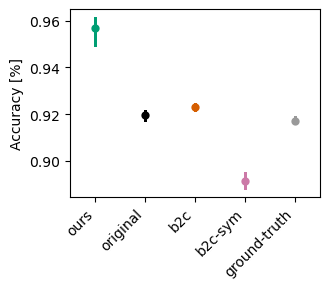

Saved to results/publication_oup_revision/downstream_tasks/cell_typing_synthetic/accuracy.pdf


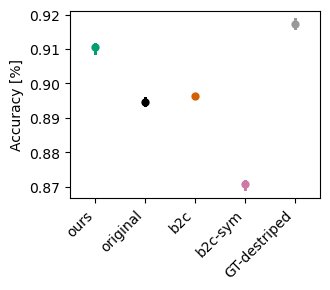

In [ ]:
from src.experiments_analysis.plots_ismb import color_dict

_PLOT_RENAMES = {"GT": "GT-destriped", "GT (expectation)": "ground-truth"}
_GT_COLOR = "#999999"
_palette = {**color_dict, "GT-destriped": _GT_COLOR, "ground-truth": _GT_COLOR}
_SAVE_PATH = "results/publication_oup_vrepro/downstream_tasks/cell_typing_synthetic/accuracy.pdf"

for i, gt_key in enumerate(GT_KEYS):
    df_plot = agreement_summaries[gt_key].copy()
    df_plot["method"] = df_plot["method"].replace(_PLOT_RENAMES)

    fig, ax = plt.subplots(figsize=(3.4, 3.))
    sns.pointplot(
        data=df_plot, x="method", y="agreement_fraction",
        linestyles="", hue="method", palette=_palette, ax=ax,
        markers="o", scale=0.8,
    )
    ax.set_ylabel("Accuracy [%]")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    #ax.get_legend().remove()
    plt.tight_layout()

    # save the second plot
    if i == 1:
        from pathlib import Path as _P
        _P(_SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(_SAVE_PATH, bbox_inches="tight")
        print(f"Saved to {_SAVE_PATH}")

    plt.show()